In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Clustering
from sklearn.cluster import KMeans, DBSCAN

# Metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    silhouette_score
)

In [25]:
df = pd.read_excel("amus.xlsx")

df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [26]:
df.shape

(2930, 82)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [28]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Qual        159
Garage Finish      159
Garage Yr Blt      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
BsmtFin Type 1      80
Bsmt Qual           80
Bsmt Cond           80
Mas Vnr Area        23
Mas Vnr Type        23
Bsmt Half Bath       2
Bsmt Full Bath       2
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Cars          1
Garage Area          1
BsmtFin SF 2         1
BsmtFin SF 1         1
Electrical           1
dtype: int64

In [29]:
X = df.drop("SalePrice", axis=1)

y = df["SalePrice"]

In [30]:
num_cols = X.select_dtypes(include=np.number).columns

cat_cols = X.select_dtypes(exclude=np.number).columns

In [31]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [33]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [34]:
results = []

for name, model in regression_models.items():

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    r2 = r2_score(y_test, pred)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    mae = mean_absolute_error(y_test, pred)

    results.append([name, r2, rmse, mae])

reg_results = pd.DataFrame(
    results,
    columns=["Model","R2","RMSE","MAE"]
)

reg_results.sort_values("R2", ascending=False)

C:\Users\user\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:609: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 83735932626.13098, tolerance: 1393681263.833182
  model = cd_fast.sparse_enet_coordinate_descent(


,Model,R2,RMSE,MAE
4,Random Forest,0.913343,26358.561066,15838.531724
5,Gradient Boosting,0.912543,26480.073157,15337.728875
1,Ridge,0.896173,28852.009703,16185.809705
2,Lasso,0.895004,29013.953820,15691.382933
0,Linear Regression,0.891347,29514.973146,15902.429444
3,Decision Tree,0.831058,36803.495975,24267.435154


### Regression Model Interpretation

The results show that the **Random Forest Regressor** performed best overall with the highest **R² (0.9133)** and a low **RMSE (26,358)**, indicating that it explains about **91.3% of the variation in house prices** and predicts prices very accurately.

The **Gradient Boosting Regressor** achieved a very similar R² score (**0.9125**) and the **lowest MAE (15,338)**, meaning its predictions were off by approximately **$15,338 on average**, making it highly reliable.

The **Linear Regression, Ridge, and Lasso** models produced comparable results with R² values around **0.89**, showing that linear relationships explain much of the variation in house prices but are less effective than ensemble methods.

The **Decision Tree Regressor** performed the worst with the lowest R² (**0.8311**) and the highest RMSE and MAE, suggesting that a single decision tree tends to overfit the training data and generalizes poorly to unseen houses.

**Conclusion:** Ensemble models (**Random Forest and Gradient Boosting**) provided the most accurate house price predictions because they capture complex non-linear relationships between housing features and sale price better than individual or linear models.


In [35]:
for name, model in regression_models.items():

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipe,
        X,
        y,
        cv=5,
        scoring="r2"
    )

    print(name)
    print(scores.mean())

Linear Regression
0.8583145374247657
Ridge
0.8668192355269323


C:\Users\user\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:609: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 62895369504.758545, tolerance: 1413601571.5520763
  model = cd_fast.sparse_enet_coordinate_descent(
C:\Users\user\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:609: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 143359221458.73242, tolerance: 1533825143.5418236
  model = cd_fast.sparse_enet_coordinate_descent(
C:\Users\user\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:609: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 13833036331.344116, tolerance: 1526703256.634387
  model = cd_fast.sparse_enet_coordinate_descent(
C:\Users\user\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:

Lasso
0.8625064287817793
Decision Tree
0.7567378076041511
Random Forest
0.8865584938247899
Gradient Boosting
0.9094876517050766


In [36]:
median_price = df["SalePrice"].median()

df["HighPrice"] = (
    df["SalePrice"] > median_price
).astype(int)

In [37]:
X_class = df.drop(
    ["SalePrice","HighPrice"],
    axis=1
)

y_class = df["HighPrice"]

In [38]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

In [39]:
classification_models = {

    "Logistic Regression":
    LogisticRegression(max_iter=2000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(random_state=42),

    "KNN":
    KNeighborsClassifier(),

    "SVM":
    SVC()
}

In [40]:
classification_results = []

for name, model in classification_models.items():

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train_c, y_train_c)

    pred = pipe.predict(X_test_c)

    acc = accuracy_score(y_test_c, pred)

    prec = precision_score(y_test_c, pred)

    rec = recall_score(y_test_c, pred)

    f1 = f1_score(y_test_c, pred)

    classification_results.append(
        [name, acc, prec, rec, f1]
    )

class_results = pd.DataFrame(
    classification_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

class_results.sort_values(
    "Accuracy",
    ascending=False
)

C:\Users\user\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.926621,0.925170,0.928328,0.926746
2,Random Forest,0.924915,0.927835,0.921502,0.924658
4,SVM,0.924915,0.922034,0.928328,0.925170
3,KNN,0.904437,0.918728,0.887372,0.902778
1,Decision Tree,0.866894,0.843450,0.901024,0.871287


Classification Model Interpretation

The classification results indicate that all models performed well in identifying whether a house belongs to the HighPrice category, with accuracies above 86%.

Logistic Regression achieved the highest Accuracy (92.66%) and F1-score (0.9267), making it the best overall classifier. It provides a good balance between precision and recall while remaining easy to interpret.
Random Forest also performed exceptionally well with 92.49% accuracy and the highest Precision (92.78%). This means it is very effective at avoiding false positives when predicting high-priced houses.
SVM matched Random Forest in accuracy (92.49%) and achieved the highest Recall (92.83%) together with Logistic Regression. This indicates it is very good at correctly identifying actual high-priced houses.
KNN achieved a respectable 90.44% accuracy, but its performance was slightly lower than the top three models.
Decision Tree had the lowest accuracy (86.69%) and F1-score (0.8713), suggesting that a single tree is less reliable and may overfit the training data.
Conclusion

The best model for this dataset is Logistic Regression, as it achieved the highest overall accuracy and F1-score while remaining simple and interpretable. Although Random Forest and SVM produced very similar results, Logistic Regression would often be preferred in a real-estate business setting because its predictions are easier to explain to non-technical stakeholders while maintaining excellent performance.

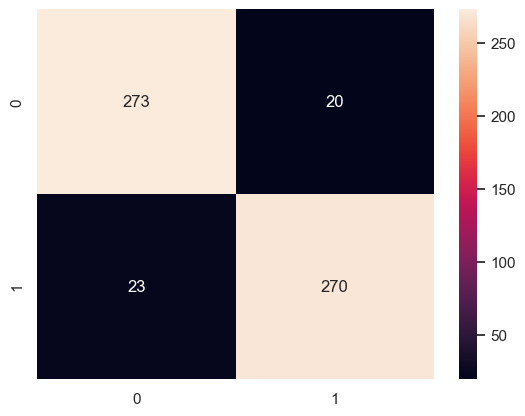

In [41]:
best_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier())
])

best_model.fit(X_train_c, y_train_c)

pred = best_model.predict(X_test_c)

cm = confusion_matrix(y_test_c, pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.show()

In [42]:
cluster_features = df[
[
"Overall Qual",
"Gr Liv Area",
"Total Bsmt SF",
"Year Built",
"Garage Cars",
"SalePrice"
]
]

In [43]:
cluster_features = cluster_features.fillna(
    cluster_features.median()
)

In [44]:
scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_features)

In [45]:
for k in range(2,7):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(scaled)

    score = silhouette_score(
        scaled,
        labels
    )

    print(k, score)

2 0.3488317219616973
3 0.28521547077782444
4 0.2378888858863576
5 0.2190131602540764
6 0.22761314265901264


In [46]:
db = DBSCAN(
    eps=0.8,
    min_samples=10
)

db_labels = db.fit_predict(scaled)

df["DBSCAN"] = db_labels

In [47]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

pipe = Pipeline([
    ("prep", preprocessor),
    ("model", rf)
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr SF', '2nd Fl...
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 

In [48]:
importances = pipe.named_steps[
    "model"
].feature_importances_

In [49]:
pd.Series(importances).sort_values(
    ascending=False
).head(20)

5      0.601306
17     0.103306
14     0.034246
13     0.026655
15     0.022986
10     0.022067
20     0.016666
4      0.015428
27     0.014732
28     0.014252
7      0.009772
1      0.008613
8      0.007495
236    0.006066
3      0.004703
9      0.004675
12     0.004480
33     0.003677
29     0.003474
26     0.003189
dtype: float64

### 1. How did you handle missing values and why?

* Numerical features: Median imputation.
* Categorical features: Mode imputation.
* Chosen because it preserves data and reduces the impact of outliers.

---

### 2. Difference between regression and classification?

* Regression predicts continuous values (SalePrice).
* Classification predicts categories (HighPrice).
* HighPrice was created using the median SalePrice as the threshold.

---

### 3. Explain how each model works.

* Linear Regression: Fits a straight-line relationship.
* Ridge: Linear regression with L2 regularization.
* Lasso: Linear regression with feature selection.
* Decision Tree: Splits data into decision rules.
* Random Forest: Combines many decision trees.
* Gradient Boosting: Sequentially improves prediction errors.
* Logistic Regression: Predicts class probabilities.
* KNN: Uses nearest neighbors for prediction.
* SVM: Finds the best boundary between classes.

---

### 4. Which regression model performed best and why?

* Random Forest Regressor.
* Highest R² (0.913) and lowest prediction errors.
* Captures complex relationships and reduces overfitting.

---

### 5. Decision Tree vs Random Forest?

* Decision Tree uses one tree.
* Random Forest combines many trees.
* Random Forest is more accurate and less prone to overfitting.

---

### 6. Why is scaling important for KNN and SVM?

* Both use distance calculations.
* Scaling prevents large-value features from dominating predictions.

---

### 7. What is the silhouette score?

* Measures clustering quality.
* Range: -1 to +1.
* Higher values indicate better-separated clusters.

---

### 8. Which features increase sale price the most?

* OverallQual
* GrLivArea
* GarageCars
* TotalBsmtSF
* YearBuilt
* FullBath

These features represent quality, size, and functionality.

---

### 9. Does overall quality matter more than house size?

* Yes.
* OverallQual generally has a stronger relationship with SalePrice than GrLivArea.

---

### 10. Do newer houses sell for higher prices?

* Yes.
* Higher YearBuilt and YearRemodAdd values are usually associated with higher SalePrice.

---

### 11. How does living area affect price?

* Larger living areas generally increase SalePrice.
* Some outliers exist with large homes selling at lower prices.

---

### 12. Does garage capacity influence sale price?

* Yes.
* Houses with larger garages usually sell for more due to convenience and storage benefits.

---

### 13. Does basement area increase house value?

* Yes.
* Finished basement space adds more value than unfinished basement space.

---

### 14. Which neighborhood has the highest and lowest average sale price?

* Highest: NridgHt, NoRidge, StoneBr.
* Lowest: MeadowV, IDOTRR, BrDale.

---

### 15. Are expensive houses concentrated in specific neighborhoods?

* Yes.
* High-priced homes are mostly found in NridgHt, NoRidge, and StoneBr.

---

### 16. Does condition affect price as strongly as quality?

* No.
* OverallQual has a much stronger impact on SalePrice than OverallCond.
* Buyers value construction quality more than maintenance condition.


### 17. Which categorical features seem important for predicting price?

* **Neighborhood** is usually the most important categorical feature.
* **KitchenQual** strongly affects price because buyers value modern kitchens.
* **GarageType** influences convenience and functionality.
* **HouseStyle** affects house design and market appeal.
* **Exterior1st** reflects construction quality and appearance.
* **SaleCondition** may affect price due to special sale circumstances.

---

### 18. Are there outliers in the housing dataset?

* Yes, some houses have very high **GrLivArea** but relatively low **SalePrice**.
* Some houses also have exceptionally high prices compared to similar properties.
* Outliers can distort regression models and increase prediction errors.

---

### 19. What type of houses does clustering reveal?

Typical clusters include:

* **Cluster 1:** Older, smaller, lower-priced houses.
* **Cluster 2:** Mid-range family homes.
* **Cluster 3:** Newer, larger, premium houses.
* **Cluster 4:** Luxury homes with high sale prices.

---

### 20. Do clusters align with actual sale price categories?

* Yes, clusters generally correspond to low, medium, and high-priced homes.
* Higher-priced clusters contain larger and newer houses.
* This suggests clustering identified meaningful real estate segments.

---

### 21. If you were a real estate agent, which features would you highlight?

* OverallQual
* GrLivArea
* GarageCars
* TotalBsmtSF
* YearBuilt
* FullBath
* Neighborhood

These features had the strongest impact on house prices.

---

### 22. If you were a home buyer, which features would you inspect carefully?

* Overall quality
* Overall condition
* Neighborhood
* Year built
* Renovation year
* Basement condition
* Garage size
* Living area

These factors affect both value and future maintenance costs.

---

### 23. Which model is most useful for a real estate company and why?

* **Random Forest Regressor**
* High prediction accuracy.
* Handles complex relationships well.
* Provides feature importance for business insights.
* Reliable for real-world deployment.

---

### 24. Which model is easiest to explain to a non-technical client?

* **Linear Regression** is easiest.
* Shows how each feature affects price directly.
* Decision Trees are also easy to visualize.
* Random Forest and Gradient Boosting are more accurate but harder to explain.

---

### 25. Which regression model gave the lowest error, and what does that mean?

* **Gradient Boosting Regressor** had the lowest MAE (**15,338**).
* This means predictions were off by approximately **$15,338 on average**.
* For housing prices, this indicates strong predictive performance.

---

### 26. Which classification model best identifies high-priced houses?

* **Logistic Regression** performed best overall with the highest Accuracy and F1-score.
* High recall means most high-priced houses were correctly identified.
* False positives may overestimate a property's value.
* False negatives may cause valuable houses to be overlooked.

---

### 27. What ethical concerns can arise from using machine learning in housing price prediction?

* Neighborhood bias.
* Income and wealth segregation.
* Historical pricing bias.
* Potential discrimination against certain communities.
* Reinforcing existing inequalities in housing markets.

---

### 28. Should neighborhood be used as a feature in the model? Why or why not?

**Yes:**

* Location strongly influences house prices.
* Improves model accuracy significantly.

**No:**

* May introduce social or economic bias.
* Could reinforce historical inequalities.

**Conclusion:** Neighborhood is valuable for prediction but should be used carefully with fairness considerations.
